# Стадии сна — Стекинг трёх бустингов (LightGBM + XGBoost + CatBoost)

**Задача.** Предсказать `sleep_stage` ∈ {0,1,2,3}. **Метрика.** macro-F1.

Развиваем идею из блендинга: вместо ручных весов учим **мета-классификатор** поверх OOF-вероятностей трёх бустингов.

**Стекинг без утечки:**
1. Каждая база (LightGBM / XGBoost / CatBoost) даёт **OOF-вероятности** на общих фолдах → мета-признаки (3×4=12).
2. **Мета-модель** (логистическая регрессия) учится взвешивать базы по классам; оценивается на **отдельном** разбиении.
3. На test: базы рефитятся на полном train → мета-модель даёт финальный ответ.

Параметры баз берём **уже найденные** (без повторного тюнинга — быстро). Сравним честно: лучшая одиночная →
взвешенный блендинг → **стекинг**. После каждой ячейки — короткий вывод.

## 0. Подготовка и конфигурации баз (уже оттюнены)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, itertools
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RS = 42

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
ss = pd.read_csv("sample_submission.csv")
target = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]
y = train[target].values
classes = sorted(np.unique(y)); n_class = len(classes)
CV = StratifiedKFold(5, shuffle=True, random_state=RS)
def mf(p): return f1_score(y, np.asarray(p).argmax(1), average="macro")

LGB_PARAMS = dict(objective="multiclass", num_class=n_class, metric="multi_logloss",
                  learning_rate=0.03, num_leaves=15, min_child_samples=20,
                  feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, verbosity=-1, n_jobs=-1)
XGB_BEST = dict(objective="multi:softprob", num_class=n_class, eval_metric="mlogloss",
                eta=0.03, max_depth=6, min_child_weight=3, subsample=0.8,
                colsample_bytree=0.8, tree_method="hist", verbosity=0)
CAT_DEPTH, CAT_LR = 6, 0.06
print("Базы: LightGBM, XGBoost(max_depth=6,eta=0.03), CatBoost(depth=6,lr=0.06). Готово.")
# Вывод: три разнородные по реализации бустинга с лучшими найденными параметрами — основа для стекинга.

Базы: LightGBM, XGBoost(max_depth=6,eta=0.03), CatBoost(depth=6,lr=0.06). Готово.


## 1. OOF-вероятности трёх баз (мета-признаки)
Все три — на общих фолдах `StratifiedKFold(5, seed=42)`, чтобы мета-признаки были согласованы и без утечки.

In [2]:
def oof_lgbm(p, seed=RS):
    oof=np.zeros((len(train),n_class)); it=[]; p=dict(p,seed=seed)
    for tr,va in CV.split(train[features],y):
        m=lgb.train(p, lgb.Dataset(train[features].iloc[tr],y[tr]), num_boost_round=3000,
                    valid_sets=[lgb.Dataset(train[features].iloc[va],y[va])],
                    callbacks=[lgb.early_stopping(60,verbose=False), lgb.log_evaluation(0)])
        oof[va]=m.predict(train[features].iloc[va],num_iteration=m.best_iteration); it.append(m.best_iteration)
    return oof,it

def oof_xgb(p, seed=RS):
    oof=np.zeros((len(train),n_class)); it=[]; p=dict(p,seed=seed)
    for tr,va in CV.split(train[features],y):
        dtr=xgb.DMatrix(train[features].iloc[tr],label=y[tr]); dva=xgb.DMatrix(train[features].iloc[va],label=y[va])
        b=xgb.train(p,dtr,num_boost_round=3000,evals=[(dva,"v")],early_stopping_rounds=60,verbose_eval=False)
        oof[va]=b.predict(dva,iteration_range=(0,b.best_iteration+1)); it.append(b.best_iteration)
    return oof,it

def oof_cat(depth,lr, seed=RS):
    oof=np.zeros((len(train),n_class)); it=[]
    for tr,va in CV.split(train[features],y):
        m=CatBoostClassifier(iterations=800,depth=depth,learning_rate=lr,loss_function="MultiClass",
                             random_seed=seed,early_stopping_rounds=40,verbose=0,allow_writing_files=False)
        m.fit(train[features].iloc[tr],y[tr],eval_set=(train[features].iloc[va],y[va]),use_best_model=True)
        oof[va]=m.predict_proba(train[features].iloc[va]); it.append(m.get_best_iteration())
    return oof,it

lgb_oof,lgb_it = oof_lgbm(LGB_PARAMS)
xgb_oof,xgb_it = oof_xgb(XGB_BEST)
cat_oof,cat_it = oof_cat(CAT_DEPTH,CAT_LR)
print(f"LightGBM CV macro-F1 = {mf(lgb_oof):.4f}")
print(f"XGBoost  CV macro-F1 = {mf(xgb_oof):.4f}")
print(f"CatBoost CV macro-F1 = {mf(cat_oof):.4f}")
# Вывод: получены согласованные OOF-вероятности трёх баз — мета-признаки для стекинга.

LightGBM CV macro-F1 = 0.8254
XGBoost  CV macro-F1 = 0.8232
CatBoost CV macro-F1 = 0.8254


## 2. Взвешенный блендинг (для сравнения со стекингом)
Оптимизируем веса на симплексе по CV — это «ручная» альтернатива мета-модели.

In [3]:
oofs=[lgb_oof,xgb_oof,cat_oof]; grid=np.arange(0,1.0001,0.05); best=(-1,None)
for wl in grid:
    for wx in grid:
        wc=1-wl-wx
        if wc<-1e-9: continue
        s=mf(wl*oofs[0]+wx*oofs[1]+wc*oofs[2])
        if s>best[0]: best=(s,(round(wl,2),round(wx,2),round(wc,2)))
blend_f1,(WL,WX,WC)=best
print(f"блендинг: веса (LGB,XGB,CAT)=({WL},{WX},{WC})  CV macro-F1={blend_f1:.4f}")
# Вывод: фиксируем результат взвешенного блендинга — планка, которую должен побить стекинг.

блендинг: веса (LGB,XGB,CAT)=(0.2,0.25,0.55)  CV macro-F1=0.8291


## 3. Стекинг — мета-классификатор поверх OOF
Мета-признаки = конкатенация вероятностей трёх баз (12 чисел/строка). Мета-модель — логистическая регрессия.
Честная оценка: `cross_val_predict` на **другом** разбиении (seed=7), т.к. мета-признаки уже OOF.

In [4]:
meta_X = np.hstack(oofs)
meta = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0))
cv_meta = StratifiedKFold(5, shuffle=True, random_state=7)
stack_oof = cross_val_predict(meta, meta_X, y, cv=cv_meta, method="predict_proba", n_jobs=-1)
print(f"СТЕКИНГ (мета-LogReg) CV macro-F1 = {mf(stack_oof):.4f}")
# Вывод: сравним стекинг с блендингом и лучшей одиночной — иногда мета-модель не бьёт простой блендинг при похожих базах.

СТЕКИНГ (мета-LogReg) CV macro-F1 = 0.8258


## 4. Сводное сравнение

In [5]:
summary = pd.DataFrame({
    "подход": ["LightGBM","XGBoost","CatBoost","равные веса","блендинг (опт. веса)","СТЕКИНГ (мета)"],
    "CV_macroF1": [mf(lgb_oof),mf(xgb_oof),mf(cat_oof),mf(sum(oofs)/3),blend_f1,mf(stack_oof)],
}).sort_values("CV_macroF1", ascending=False)
print(summary.round(4).to_string(index=False))
print("\nДля справки: одиночный RBF-SVM ≈ 0.834 (LB 0.8415)")
# Вывод: видно, дал ли стекинг прирост над блендингом и где весь блок бустингов относительно SVM.

              подход  CV_macroF1
блендинг (опт. веса)      0.8291
         равные веса      0.8267
      СТЕКИНГ (мета)      0.8258
            CatBoost      0.8254
            LightGBM      0.8254
             XGBoost      0.8232

Для справки: одиночный RBF-SVM ≈ 0.834 (LB 0.8415)


## 5. Анализ ошибок — лучший из (стекинг / блендинг)

Лучший подход: блендинг (опт. веса)
              precision    recall  f1-score   support

           0      0.857     0.848     0.852      2001
           1      0.843     0.858     0.851      2442
           2      0.785     0.772     0.778      2237
           3      0.833     0.838     0.835      2320

    accuracy                          0.829      9000
   macro avg      0.829     0.829     0.829      9000
weighted avg      0.829     0.829     0.829      9000



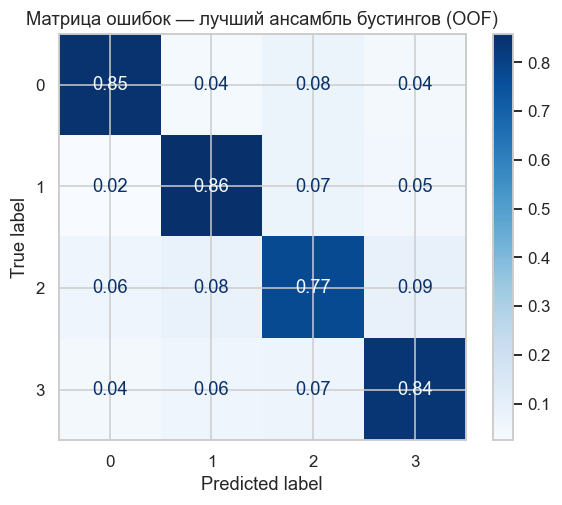

In [6]:
use_stack = mf(stack_oof) >= blend_f1
best_oof = stack_oof if use_stack else (WL*oofs[0]+WX*oofs[1]+WC*oofs[2])
print("Лучший подход:", "СТЕКИНГ" if use_stack else "блендинг (опт. веса)")
pred_oof = best_oof.argmax(1)
print(classification_report(y, pred_oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, pred_oof, normalize="true",
                                        display_labels=classes, cmap="Blues", values_format=".2f")
plt.title("Матрица ошибок — лучший ансамбль бустингов (OOF)"); plt.show()
# Вывод: класс 2 остаётся узким местом; смотрим, подтянул ли ансамбль его recall.

## 6. Финальная модель и сабмит
Рефитим базы на полном train, мета-модель (обученная на полных OOF) даёт ответ. Если стекинг не побил блендинг —
используем веса блендинга (fallback).

In [7]:
lgb_full=lgb.train(LGB_PARAMS, lgb.Dataset(train[features],y), num_boost_round=int(np.mean(lgb_it)))
lgb_te=lgb_full.predict(test[features])
xgb_full=xgb.train(XGB_BEST, xgb.DMatrix(train[features],label=y), num_boost_round=int(np.mean(xgb_it)))
xgb_te=xgb_full.predict(xgb.DMatrix(test[features]))
cat_full=CatBoostClassifier(iterations=int(np.mean(cat_it)),depth=CAT_DEPTH,learning_rate=CAT_LR,
                            loss_function="MultiClass",random_seed=RS,verbose=0,allow_writing_files=False)
cat_full.fit(train[features],y)
cat_te=cat_full.predict_proba(test[features])

if use_stack:
    meta_full=meta.fit(meta_X,y)
    proba_te=meta_full.predict_proba(np.hstack([lgb_te,xgb_te,cat_te]))
else:
    proba_te=WL*lgb_te+WX*xgb_te+WC*cat_te
pred_te=proba_te.argmax(1)

submission=pd.DataFrame({"id":test["id"],target:pred_te})[ss.columns]
submission.to_csv("submission_stack3.csv", index=False)
print(f"Финальный CV macro-F1 = {mf(best_oof):.4f}  ({'стекинг' if use_stack else 'блендинг'})")
print("Сохранено submission_stack3.csv:", submission.shape)
print(pd.DataFrame({"train":pd.Series(y).value_counts(normalize=True).sort_index(),
                    "test_pred":pd.Series(pred_te).value_counts(normalize=True).sort_index()}).round(3))
submission.head()
# Вывод: финальный сабмит — стекинг/блендинг трёх бустингов без утечки; распределение близко к train.

Финальный CV macro-F1 = 0.8291  (блендинг)
Сохранено submission_stack3.csv: (5000, 2)
   train  test_pred
0  0.222      0.224
1  0.271      0.260
2  0.249      0.255
3  0.258      0.261


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 7. Итоги
- **Стекинг без утечки:** мета-признаки — OOF-вероятности трёх баз, мета-модель оценена на отдельном разбиении.
- **Честное сравнение** (раздел 4): стекинг vs блендинг vs лучшая одиночная.
- **Оговорка:** мета и веса настроены на OOF → лёгкий оптимизм; на новых данных эффект меньше.
- **Контекст:** LightGBM/XGBoost/CatBoost — одно семейство и сильно скоррелированы, поэтому и стекинг даёт малый прирост
  и остаётся ниже RBF-SVM (LB 0.8415). Реальную разнородность дал бы стекинг **бустингов вместе с SVM**, а не трёх деревьев между собой.